In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from lifelines import KaplanMeierFitter

In [4]:
df_OS_data = pd.read_csv("/home/macraedc/rt_pred_results/OS_Test/Trial_2/KFold2/model_predictions.csv", sep=';', index_col='PatientID')
df_OS_data

df_train_val = df_OS_data[df_OS_data['Mode'] == 'val']
df_test = df_OS_data[df_OS_data['Mode'] == 'test']

In [75]:
df_train_val

,Mode,Xerostomia_M06_pred,Xerostomia_M06_true,OS_pred,OS_event_true,OS_months_true
PatientID,,,,,,
10785,val,0.257455,0.0,-0.008459,1.0,11.0
11247,val,0.424824,1.0,-0.198650,0.0,1309.0
11867,val,0.481349,0.0,-0.321587,0.0,1387.0
12260,val,0.020730,0.0,0.504718,0.0,736.0
12609,val,0.552921,1.0,-0.474159,0.0,1042.0
...,...,...,...,...,...,...
97255,val,0.398143,-1.0,-0.224554,1.0,46.0
98112,val,0.457584,0.0,-0.296399,1.0,36.0
99034,val,0.547709,1.0,-0.521755,0.0,670.0


<Axes: xlabel='timeline'>

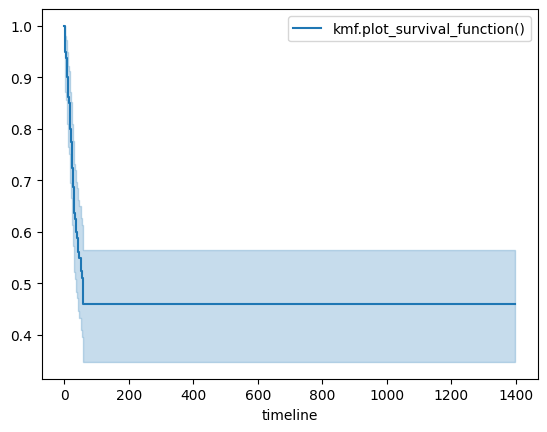

In [5]:
T = df_train_val['OS_months_true'].values
E = df_train_val['OS_event_true'].values
preds = df_train_val['OS_pred'].values

kmf = KaplanMeierFitter()
ax = kmf.fit(T, E, label="kmf.plot_survival_function()")

kmf.plot_survival_function()

In [6]:
preds_dict = {"OS" : df_train_val["OS_pred"].values}

labels_dict = {"OS": np.stack([df_train_val["OS_event_true"].values, df_train_val["OS_months_true"].values], axis=1)}


40
(40,) (40,)


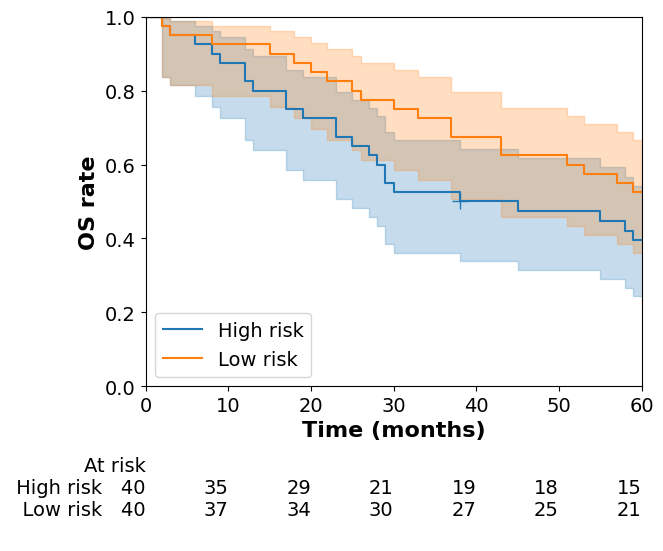

In [ ]:
def kaplan_meier_subplot(config, ax, y_preds, event_labels, time_labels):
    # seperate the predictions into a high risk and low risk group, using the median prediction as the threshold
    median_pred = np.median(y_preds)
    lowrisk_group_list = np.where(y_preds < median_pred)[0]
    highrisk_group_list = np.where(y_preds >= median_pred)[0]

    # event_labels = labels_dict["OS"][:, 0]
    # time_labels = labels_dict["OS"][:, 1]

    print(len(lowrisk_group_list))

    #print(preds_dict["OS"][lowrisk_group_list].shape, preds_dict["OS"][highrisk_group_list].shape)

    kmf_1 = KaplanMeierFitter()
    kmf_1.fit(time_labels[highrisk_group_list], event_labels[highrisk_group_list], label='High risk').plot_survival_function(ax=ax, show_censors=True, ci_show=True)

    kmf_0 = KaplanMeierFitter()
    kmf_0.fit(time_labels[lowrisk_group_list], event_labels[lowrisk_group_list], label='Low risk').plot_survival_function(ax=ax, show_censors=True, ci_show=True)
    
    from lifelines.plotting import add_at_risk_counts
    
    #add_at_risk_counts(kmf_1, ax=ax, fontsize=14, rows_to_show=['At risk']) 
    ax.set_xlim(0,60)
    ax.set_ylim(0.0, 1.0)

    add_at_risk_counts(kmf_1, kmf_0, ax=ax, fontsize=14, rows_to_show=['At risk'])

    ax.set_ylabel("OS rate", fontsize = 16, fontweight = 'bold') # new
    ax.set_xlabel('Time (months)',fontsize = 16, fontweight = 'bold')
    ax.legend( loc='lower left', prop={ 'size': 14})
        
    ax.tick_params(axis='both',labelsize = 14) 

    # return ax 

    # plt.tight_layout()
    # plt.show()


plt.figure()
ax = plt.subplot(111)

config = {}

kaplan_meier_subplot(config, ax, preds_dict, labels_dict)

plt.show()

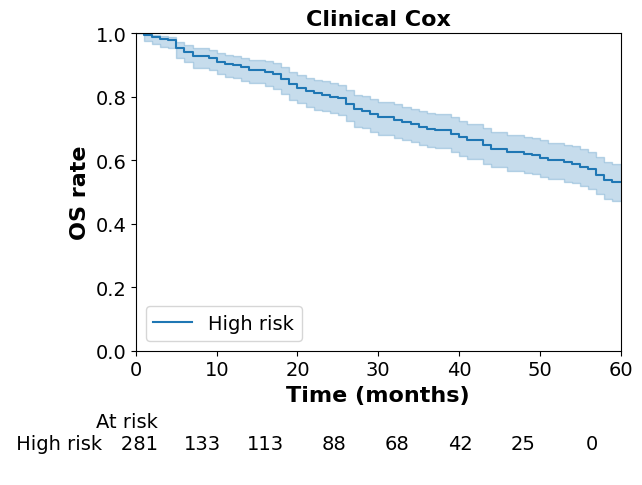

In [40]:
from lifelines.plotting import add_at_risk_counts

plt.figure()
ax = plt.subplot(111)
kmf_0 = KaplanMeierFitter()
ax = kmf_0.fit(T, E,label='High risk').plot_survival_function(ax=ax,ci_show=True)
# kmf_1 = KaplanMeierFitter()
# ax = kmf_1.fit(df_test.loc[lowrisk_group_list][time_e], df_test.loc[lowrisk_group_list][event],label='Low risk').plot_survival_function(ax=ax,show_censors=True,ci_show=False)
add_at_risk_counts(kmf_0, ax=ax, fontsize = 14 ,rows_to_show = ['At risk'] )
plt.tight_layout()

plt.ylim([0.0,1.0])
ax.set_xlim(0,60)
ax.set_ylabel("OS rate", fontsize = 16, fontweight = 'bold') # new
ax.set_xlabel('Time (months)',fontsize = 16, fontweight = 'bold')
ax.legend( loc='lower left', prop={ 'size': 14})
    
ax.tick_params(axis='both',labelsize = 14)   
plt.title("Clinical Cox" , fontsize = 16, fontweight = 'bold') # new  
plt.show() 